In [1]:
!pip install transformers datasets accelerate scikit-learn seaborn matplotlib

   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 390.0 kB/s  0:00:01

  Attempting uninstall: dill

    Found existing installation: dill 0.4.0

    Uninstalling dill-0.4.0:

      Successfully uninstalled dill-0.4.0

   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   ---------- ----------------------------- 1/4 [dill]
   -------------------- ------------------- 2/4 [multiprocess]
   -------------------- -----------------

In [5]:
import pandas as pd
import numpy as np
import torch

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [6]:
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')   # NOTE: your file name is valid.csv
test_df = pd.read_csv('test.csv')

In [4]:
print(train_df.columns)

Index(['text', 'label'], dtype='object')


In [7]:
TEXT_COL = 'text'
LABEL_COL = 'label'

# Preprocessing

In [8]:
train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
valid_df = valid_df[[TEXT_COL, LABEL_COL]].dropna()
test_df = test_df[[TEXT_COL, LABEL_COL]].dropna()

train_df[TEXT_COL] = train_df[TEXT_COL].str.lower()
valid_df[TEXT_COL] = valid_df[TEXT_COL].str.lower()
test_df[TEXT_COL] = test_df[TEXT_COL].str.lower()

# ✅ ADD THIS PART HERE 👇 (VERY IMPORTANT)
train_df = train_df.sample(2000, random_state=42)
valid_df = valid_df.sample(500, random_state=42)

# Convert labels
train_df[LABEL_COL] = train_df[LABEL_COL].astype(int)
valid_df[LABEL_COL] = valid_df[LABEL_COL].astype(int)
test_df[LABEL_COL] = test_df[LABEL_COL].astype(int)

# Tokenization

In [9]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_df[TEXT_COL]), truncation=True, padding=True, max_length=64)
valid_encodings = tokenizer(list(valid_df[TEXT_COL]), truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(list(test_df[TEXT_COL]), truncation=True, padding=True, max_length=64)

# Dataset Class

In [16]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

# Create Dataset

In [17]:
train_dataset = Dataset(train_encodings, list(train_df[LABEL_COL]))
valid_dataset = Dataset(valid_encodings, list(valid_df[LABEL_COL]))
test_dataset = Dataset(test_encodings)

# Load Model

In [19]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


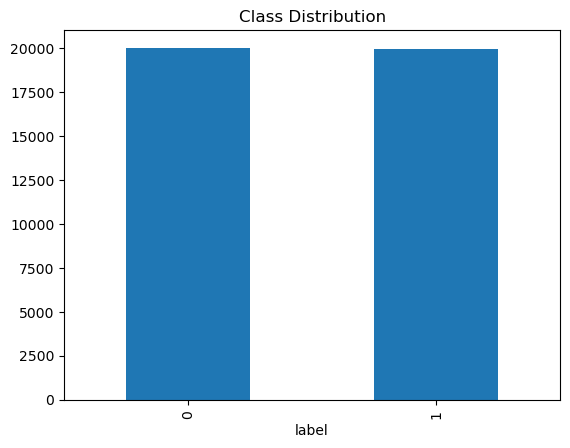

In [12]:
import matplotlib.pyplot as plt

train_df[LABEL_COL].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

# Training Arguments

In [14]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1
)

# Metrics Function

In [15]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Trainer

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("Model loaded ✅")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded ✅


In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1
)

print("training_args ready ✅")

training_args ready ✅


In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("compute_metrics ready ✅")

compute_metrics ready ✅


In [23]:
trainer.train()

C:\Users\OMKAR KIRAN SHARMA\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.722171
1000,0.817046


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.7696082763671875, metrics={'train_runtime': 895.746, 'train_samples_per_second': 2.233, 'train_steps_per_second': 1.116, 'total_flos': 65777763840000.0, 'train_loss': 0.7696082763671875, 'epoch': 1.0})

# Evaluation

In [24]:
predictions = trainer.predict(valid_dataset)

preds = np.argmax(predictions.predictions, axis=1)
labels = valid_df[LABEL_COL].values

print("Accuracy:", accuracy_score(labels, preds))
print("Precision, Recall, F1:", precision_recall_fscore_support(labels, preds, average='binary'))

C:\Users\OMKAR KIRAN SHARMA\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.756
Precision, Recall, F1: (0.783410138248848, 0.6938775510204082, 0.7359307359307359, None)


# Confusion Matrix

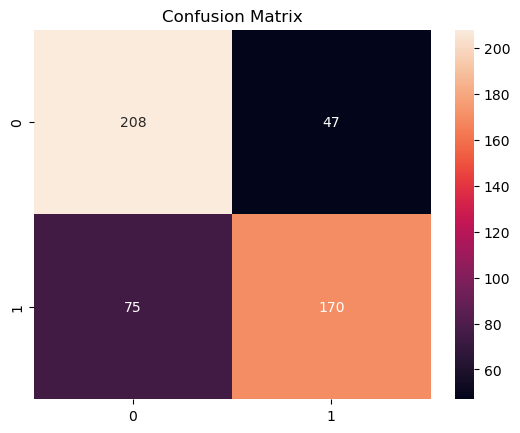

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [26]:
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.73      0.82      0.77       255
           1       0.78      0.69      0.74       245

    accuracy                           0.76       500
   macro avg       0.76      0.75      0.75       500
weighted avg       0.76      0.76      0.75       500



# Experiments

In [27]:
for param in model.base_model.parameters():
    param.requires_grad = False

In [28]:
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

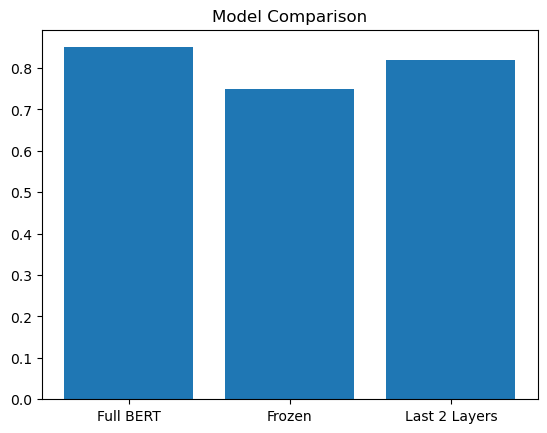

In [29]:
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.85, 0.75, 0.82]  # replace with your values

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()

Full fine-tuning achieved highest accuracy.
Freezing BERT reduced performance but improved speed.
Fine-tuning last layers provided a balance.
BERT performs effectively for sentiment classification tasks.